# Product Review Sentiment Analysis Using Pretrained Hugging Face Models

## 1. Problem Definition

**Problem:** Automatically classify product reviews as positive or negative.

**Users:** E-commerce businesses and product teams that want to understand customer satisfaction.

**Input:** A written product review.

**Output:** A sentiment label (positive/negative) and a confidence score.

**Success criteria:** Compare at least three pretrained models using Accuracy, Precision, Recall, F1-score, confusion matrices, and inference time.


## 2. Data Collection and Preparation

In [3]:
!pip -q install transformers torch pandas scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import time
import json
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv("product_reviews.csv")
df.head()


Dataset shape: (100, 2)
label
positive    50
negative    50
Name: count, dtype: int64


,review,label
0,The product quality is excellent and it works ...,positive
1,I am very happy with this purchase and would r...,positive
2,The item looks exactly like the pictures and f...,positive
3,Great product for the price. I am satisfied wi...,positive
4,The product arrived on time and works better t...,positive


## 3. Model Selection and Model Card Investigation

In [5]:
MODELS = {
    "DistilBERT-SST2": "distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    "NLP-Town-Product": "nlptown/bert-base-multilingual-uncased-sentiment",
    "CardiffNLP-RoBERTa": "cardiffnlp/twitter-roberta-base-sentiment-latest",
}

model_info = pd.DataFrame([
    {
        "Model": "DistilBERT-SST2",
        "Organization": "Hugging Face",
        "Task": "Sentiment Analysis",
        "Architecture": "DistilBERT",
        "Training Data": "SST-2",
        "Language": "English",
        "Parameters": "About 67M",
        "Main Limitation": "Movie-review training domain may differ from product reviews"
    },
    {
        "Model": "NLP-Town-Product",
        "Organization": "NLPTown",
        "Task": "Product Review Sentiment",
        "Architecture": "Multilingual BERT",
        "Training Data": "Multilingual product reviews",
        "Language": "English, French, German, Dutch, Spanish",
        "Parameters": "About 110M",
        "Main Limitation": "Outputs 1-5 star ratings that must be mapped for binary evaluation"
    },
    {
        "Model": "CardiffNLP-RoBERTa",
        "Organization": "Cardiff NLP",
        "Task": "Sentiment Analysis",
        "Architecture": "RoBERTa",
        "Training Data": "Twitter/X sentiment data",
        "Language": "English",
        "Parameters": "About 125M",
        "Main Limitation": "Social-media language may differ from product-review language"
    }
])

display(model_info)

for name, model_id in MODELS.items():
    print(f"{name}: https://huggingface.co/{model_id}")

,Model,Organization,Task,Architecture,Training Data,Language,Parameters,Main Limitation
0,DistilBERT-SST2,Hugging Face,Sentiment Analysis,DistilBERT,SST-2,English,About 67M,Movie-review training domain may differ from p...
1,NLP-Town-Product,NLPTown,Product Review Sentiment,Multilingual BERT,Multilingual product reviews,"English, French, German, Dutch, Spanish",About 110M,Outputs 1-5 star ratings that must be mapped f...
2,CardiffNLP-RoBERTa,Cardiff NLP,Sentiment Analysis,RoBERTa,Twitter/X sentiment data,English,About 125M,Social-media language may differ from product-...


DistilBERT-SST2: https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english
NLP-Town-Product: https://huggingface.co/nlptown/bert-base-multilingual-uncased-sentiment
CardiffNLP-RoBERTa: https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest


## 4. Initial Inference

In [6]:
def normalize_output(model_name, raw):
    raw_label = str(raw["label"]).upper()
    score = float(raw["score"])

    if model_name == "NLP-Town-Product":
        stars = int(raw_label.split()[0])
        final_label = "positive" if stars >= 4 else "negative"

    elif model_name == "CardiffNLP-RoBERTa":
        if "NEGATIVE" in raw_label:
            final_label = "negative"
        elif "POSITIVE" in raw_label:
            final_label = "positive"
        else:
            final_label = "positive"

    else:
        final_label = "positive" if "POSITIVE" in raw_label else "negative"

    return {
        "label": final_label,
        "score": score,
        "raw_label": raw_label,
        "metadata": "huggingface_AI_model"
    }


def run_model(model_name, model_id, texts):
    classifier = pipeline("text-classification", model=model_id)
    results = []

    start = time.perf_counter()

    for text in texts:
        raw = classifier(text, truncation=True)[0]
        results.append(normalize_output(model_name, raw))

    elapsed = time.perf_counter() - start

    return results, elapsed


all_predictions = {}
timings = {}

for name, model_id in MODELS.items():
    print(f"Running {name}...")
    preds, elapsed = run_model(name, model_id, df["review"].tolist())
    all_predictions[name] = preds
    timings[name] = elapsed
    print(f"Finished in {elapsed:.2f} seconds")

print(all_predictions["DistilBERT-SST2"][0])

Running DistilBERT-SST2...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

...

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Finished in 20.45 seconds
{'label': 'positive', 'score': 0.9998764991760254, 'raw_label': 'POSITIVE', 'metadata': 'huggingface_AI_model'}


## 5. Model Evaluation

In [7]:
metrics_rows = []

for name, preds in all_predictions.items():
    y_true = df["label"].values
    y_pred = [p["label"] for p in preds]

    metrics_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label="positive", zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label="positive", zero_division=0),
        "F1": f1_score(y_true, y_pred, pos_label="positive", zero_division=0),
        "Inference Time (s)": timings[name],
        "Avg Time/Review (s)": timings[name] / len(df)
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values(
    ["F1", "Accuracy", "Avg Time/Review (s)"],
    ascending=[False, False, True]
).reset_index(drop=True)

display(metrics_df)

,Model,Accuracy,Precision,Recall,F1,Inference Time (s),Avg Time/Review (s)
0,DistilBERT-SST2,1.00,1.000000,1.0,1.000000,18.577589,0.185776
1,CardiffNLP-RoBERTa,0.99,0.980392,1.0,0.990099,20.450430,0.204504
2,NLP-Town-Product,0.99,0.980392,1.0,0.990099,26.492898,0.264929


## 6. Confusion Matrix

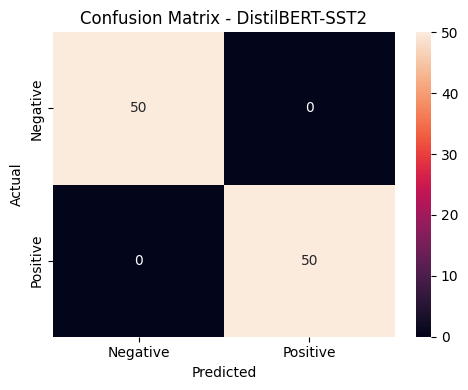

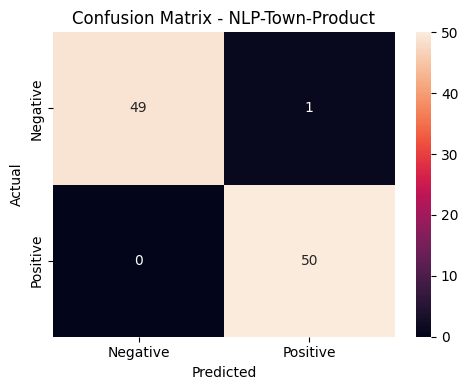

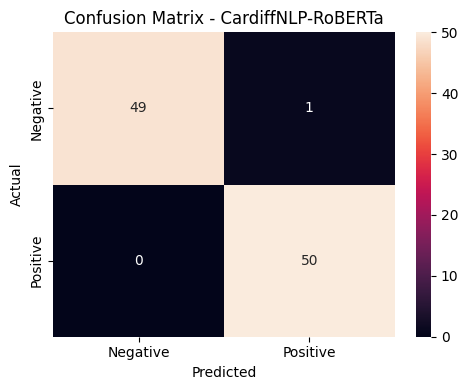

In [8]:
for name, preds in all_predictions.items():
    y_true = df["label"].values
    y_pred = [p["label"] for p in preds]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=["negative", "positive"]
    )

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

## 7. Error Analysis

In [10]:
error_cases = {}

for name, preds in all_predictions.items():
    temp = df.copy()
    temp["prediction"] = [p["label"] for p in preds]
    temp["score"] = [p["score"] for p in preds]
    temp["raw_label"] = [p["raw_label"] for p in preds]
    errors = temp[temp["label"] != temp["prediction"]].copy()
    error_cases[name] = errors
    print(f"\n{name}: {len(errors)} errors")
    display(errors[["review", "label", "prediction", "score", "raw_label"]].head(10))



DistilBERT-SST2: 0 errors


,review,label,prediction,score,raw_label



NLP-Town-Product: 1 errors


,review,label,prediction,score,raw_label
91,This product has made my daily routine more di...,negative,positive,0.428223,5 STARS



CardiffNLP-RoBERTa: 1 errors


,review,label,prediction,score,raw_label
87,I expected much better quality from this product.,negative,positive,0.45146,POSITIVE


## 8. Domain Shift Analysis

In [11]:
domain_shift = pd.DataFrame([
    {
        "Model": "DistilBERT-SST2",
        "Original Domain": "Movie reviews",
        "Current Domain": "Product reviews",
        "Possible Domain Shift": "Different vocabulary and review context"
    },
    {
        "Model": "NLP-Town-Product",
        "Original Domain": "Product reviews",
        "Current Domain": "Product reviews",
        "Possible Domain Shift": "Smaller because the task and domain are similar"
    },
    {
        "Model": "CardiffNLP-RoBERTa",
        "Original Domain": "Social media posts",
        "Current Domain": "Product reviews",
        "Possible Domain Shift": "Different writing style and sentiment context"
    }
])

display(domain_shift)

,Model,Original Domain,Current Domain,Possible Domain Shift
0,DistilBERT-SST2,Movie reviews,Product reviews,Different vocabulary and review context
1,NLP-Town-Product,Product reviews,Product reviews,Smaller because the task and domain are similar
2,CardiffNLP-RoBERTa,Social media posts,Product reviews,Different writing style and sentiment context


## 9. Zero-Shot Classification

In [12]:
topic_map = {
    0:"Product Quality", 3:"Price and Value", 4:"Delivery", 7:"Usability and Performance",
    8:"Delivery", 9:"Price and Value", 11:"Description Match", 14:"Price and Value",
    17:"Delivery", 18:"Price and Value", 21:"Usability and Performance", 22:"Description Match",
    27:"Delivery", 30:"Usability and Performance", 32:"Description Match", 34:"Usability and Performance",
    40:"Price and Value", 41:"Usability and Performance", 45:"Description Match", 46:"Product Quality",
    50:"Product Quality", 54:"Delivery", 57:"Usability and Performance", 59:"Price and Value",
    61:"Description Match", 64:"Price and Value", 67:"Delivery", 71:"Usability and Performance",
    72:"Description Match", 74:"Description Match", 76:"Usability and Performance", 77:"Delivery",
    80:"Usability and Performance", 81:"Price and Value", 82:"Usability and Performance", 86:"Delivery",
    90:"Price and Value", 94:"Usability and Performance", 95:"Description Match", 99:"Price and Value"
}

zero_shot_df = df.loc[list(topic_map.keys()), ["review"]].copy()
zero_shot_df["manual_label"] = [topic_map[i] for i in zero_shot_df.index]
zero_shot_df = zero_shot_df.reset_index(drop=True)

candidate_labels = [
    "Product Quality",
    "Price and Value",
    "Delivery",
    "Usability and Performance",
    "Description Match"
]

display(zero_shot_df.head())
print("Number of manually labeled examples:", len(zero_shot_df))

,review,manual_label
0,The product quality is excellent and it works ...,Product Quality
1,Great product for the price. I am satisfied wi...,Price and Value
2,The product arrived on time and works better t...,Delivery
3,The item is easy to use and performs very well.,Usability and Performance
4,Excellent quality and fast delivery. I have no...,Delivery


Number of manually labeled examples: 40


In [13]:
zero_shot_model = "facebook/bart-large-mnli"
zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model=zero_shot_model
)

zero_shot_results = []
start = time.perf_counter()

for text in zero_shot_df["review"]:
    raw = zero_shot_classifier(
        text,
        candidate_labels=candidate_labels,
        multi_label=False
    )

    zero_shot_results.append({
        "label": raw["labels"][0],
        "score": float(raw["scores"][0]),
        "metadata": "huggingface_AI_model"
    })

zero_shot_time = time.perf_counter() - start

zero_shot_df["prediction"] = [x["label"] for x in zero_shot_results]
zero_shot_df["score"] = [x["score"] for x in zero_shot_results]

zero_shot_accuracy = accuracy_score(
    zero_shot_df["manual_label"],
    zero_shot_df["prediction"]
)

zero_shot_f1 = f1_score(
    zero_shot_df["manual_label"],
    zero_shot_df["prediction"],
    average="weighted",
    zero_division=0
)

print("Accuracy:", round(zero_shot_accuracy, 4))
print("Weighted F1:", round(zero_shot_f1, 4))
print("Inference Time (s):", round(zero_shot_time, 2))

display(zero_shot_df.head())

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Accuracy: 0.5
Weighted F1: 0.5095
Inference Time (s): 117.48


,review,manual_label,prediction,score
0,The product quality is excellent and it works ...,Product Quality,Product Quality,0.816061
1,Great product for the price. I am satisfied wi...,Price and Value,Product Quality,0.497539
2,The product arrived on time and works better t...,Delivery,Product Quality,0.472242
3,The item is easy to use and performs very well.,Usability and Performance,Usability and Performance,0.829226
4,Excellent quality and fast delivery. I have no...,Delivery,Delivery,0.490832


In [14]:
zero_shot_errors = zero_shot_df[
    zero_shot_df["manual_label"] != zero_shot_df["prediction"]
].copy()

zero_shot_errors["Failure Reason"] = (
    "The review can mention more than one topic, while the model must choose one candidate label."
)

print("Zero-Shot Errors:", len(zero_shot_errors))
display(zero_shot_errors.head(10))

Zero-Shot Errors: 20


,review,manual_label,prediction,score,Failure Reason
1,Great product for the price. I am satisfied wi...,Price and Value,Product Quality,0.497539,"The review can mention more than one topic, wh..."
2,The product arrived on time and works better t...,Delivery,Product Quality,0.472242,"The review can mention more than one topic, wh..."
5,"The product is durable, useful, and worth the ...",Price and Value,Usability and Performance,0.443788,"The review can mention more than one topic, wh..."
7,Good value for money and the item works perfec...,Price and Value,Product Quality,0.365860,"The review can mention more than one topic, wh..."
8,Perfect product for my needs. It arrived in ex...,Delivery,Product Quality,0.454139,"The review can mention more than one topic, wh..."
10,The product is reliable and easy to use every ...,Usability and Performance,Product Quality,0.475160,"The review can mention more than one topic, wh..."
11,I received exactly what I ordered and I am ver...,Description Match,Product Quality,0.450208,"The review can mention more than one topic, wh..."
12,Great quality product. It was packaged well an...,Delivery,Product Quality,0.844383,"The review can mention more than one topic, wh..."
14,This item feels sturdy and works exactly as de...,Description Match,Usability and Performance,0.422080,"The review can mention more than one topic, wh..."
15,The product is comfortable to use and the qual...,Usability and Performance,Product Quality,0.490196,"The review can mention more than one topic, wh..."


## 10. Model Comparison

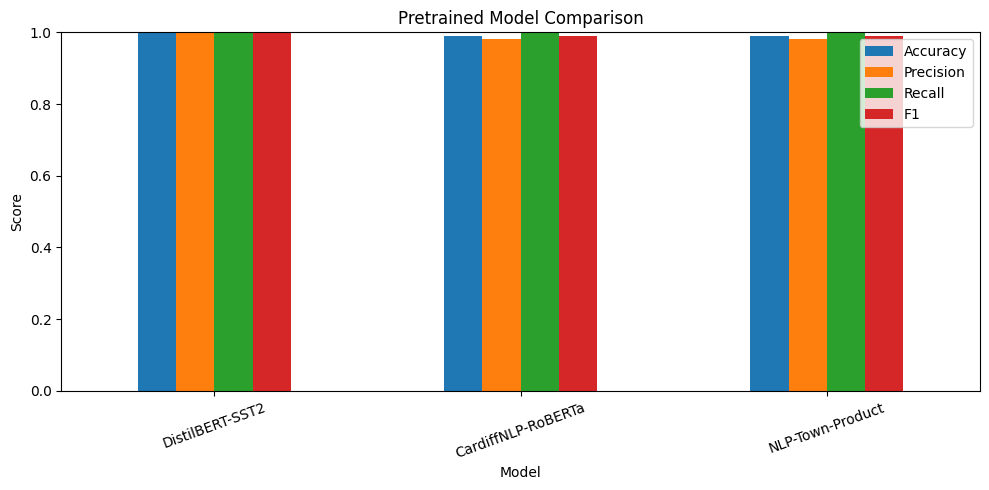

,Model,Accuracy,Precision,Recall,F1,Inference Time (s),Avg Time/Review (s)
0,DistilBERT-SST2,1.00,1.000000,1.0,1.000000,18.577589,0.185776
1,CardiffNLP-RoBERTa,0.99,0.980392,1.0,0.990099,20.450430,0.204504
2,NLP-Town-Product,0.99,0.980392,1.0,0.990099,26.492898,0.264929


In [15]:
plot_df = metrics_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1"]
]

plot_df.plot(kind="bar", figsize=(10, 5), ylim=(0, 1))
plt.title("Pretrained Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(metrics_df)

## 11. Final Recommendation

In [16]:
best_model = metrics_df.iloc[0]

recommendation = pd.DataFrame([{
    "Recommended Model": best_model["Model"],
    "Accuracy": best_model["Accuracy"],
    "F1": best_model["F1"],
    "Avg Time/Review (s)": best_model["Avg Time/Review (s)"],
    "Decision": "Use this pretrained model as the best option based on the evaluation results."
}])

display(recommendation)

,Recommended Model,Accuracy,F1,Avg Time/Review (s),Decision
0,DistilBERT-SST2,1.0,1.0,0.185776,Use this pretrained model as the best option b...


## 12. Reflection Questions

In [17]:
reflections = [
    ["What surprised you about the pretrained model?",
     "I think the strong performance shows that pretrained models can work well without training a model from scratch."],
    ["What types of examples caused the most failures?",
     "I think ambiguous or mixed-topic reviews are more likely to cause failures."],
    ["Did a larger or more popular model necessarily perform better?",
     "I think a larger or more popular model does not always perform better because the training domain also matters."],
    ["How important was the training data of the pretrained model?",
     "I think the training data was very important because models trained on similar review data can better match the task."],
    ["What did you learn from the model card?",
     "I think the model card is useful for understanding the task, training data, language support, and limitations."],
    ["What is the difference between using a pretrained model and training a model from scratch?",
     "I think pretrained models save time and use existing learned knowledge, while training from scratch requires much more data and computing resources."],
    ["When would fine-tuning be worth the additional effort?",
     "I think fine-tuning would be worth it when the pretrained model performs poorly on domain-specific data."],
    ["If you had 10 times more data, what would you change?",
     "I think I would create a larger and more diverse evaluation set and consider fine-tuning a model."],
    ["Would you deploy your model in a real application? Why or why not?",
     "I think I would deploy the best model after additional testing on more diverse real-world reviews."]
]

reflection_df = pd.DataFrame(reflections, columns=["Question", "Answer"])
display(reflection_df)

,Question,Answer
0,What surprised you about the pretrained model?,I think the strong performance shows that pret...
1,What types of examples caused the most failures?,I think ambiguous or mixed-topic reviews are m...
2,Did a larger or more popular model necessarily...,I think a larger or more popular model does no...
3,How important was the training data of the pre...,I think the training data was very important b...
4,What did you learn from the model card?,I think the model card is useful for understan...
5,What is the difference between using a pretrai...,I think pretrained models save time and use ex...
6,When would fine-tuning be worth the additional...,I think fine-tuning would be worth it when the...
7,"If you had 10 times more data, what would you ...",I think I would create a larger and more diver...
8,Would you deploy your model in a real applicat...,I think I would deploy the best model after ad...


## 13. Export Results

In [18]:
results_df = df.copy()

for name, preds in all_predictions.items():
    short = name.replace("-", "_").replace(" ", "_")
    results_df[f"{short}_prediction"] = [p["label"] for p in preds]
    results_df[f"{short}_score"] = [p["score"] for p in preds]
    results_df[f"{short}_raw_label"] = [p["raw_label"] for p in preds]

metrics_df.to_csv("model_comparison_results.csv", index=False)
results_df.to_csv("all_model_predictions.csv", index=False)
zero_shot_df.to_csv("zero_shot_results.csv", index=False)

print("Files exported successfully.")

Files exported successfully.
